Assignment 7: Magnetic Field Reconstruction with PINNs
Due on Wed 8th April at 12pm
Submit your jupyter notebook on QMPlus (tab Assessments) with name LAST_NAME_Assignment_7.ipynb

#### **Objective**  
Given a dataset of a charged particle's 3D position over time, train a PINN to reconstruct the unknown magnetic field by enforcing the Lorentz force equation.  

#### **Background**  
A charged particle with charge $q$ and mass $m$ moving in an electromagnetic field obeys the Lorentz force equation:  

$$
m \frac{d^2 \mathbf{r}}{dt^2} = q (\mathbf{E} + \mathbf{v} \times \mathbf{B})
$$

For simplicity, assume the electric field $\mathbf{E} = 0$, and $q=m=1$, so the motion is governed by the magnetic force:  

$$
 \frac{d^2 \mathbf{r}}{dt^2} =  (\mathbf{v} \times \mathbf{B})
$$
where:  
- $\mathbf{r}(t) = (x, y, z) $ is the position of the particle in time,  
- $\mathbf{v} = \frac{d\mathbf{r}}{dt}$ is the velocity,  
- $\mathbf{a} = \frac{d^2\mathbf{r}}{dt^2} $ is the acceleration,  
- $ \mathbf{B}(x, y, z) $ is the magnetic field.

  

## Task
The goal is to use a PINN to infer $\mathbf{B}$  from the observed trajectory.

#### **Steps**  

1. **Loading the data**  
   - load the csv file "Assignment_7_data.csv", which contain time, and positions $(x,y,z)$ of the particle
   - Compute velocity and acceleration numerically from the data.  

2. **Neural Network Setup**  
   - Define a neural network that takes $(x, y, z)$ as input and outputs $\mathbf{B}(x, y, z)$.  

3. **Loss Function**  
   The PINN loss should consist of:
   - **Data loss:** Ensuring that the network's predictions for $\mathbf{B}$ lead to the correct acceleration via:
     $$
     L_{\text{physics}} = \left|  \frac{d^2 \mathbf{r}}{dt^2} -  (\mathbf{v} \times \mathbf{B}) \right|
     $$
   - **Physics validity:** Include the constraint that $ div(\mathbf{B})=0$.  

4. **Training the PINN**  
   - Train the network using observed trajectories as constraints.  

5. **Validation**  
   - Validate by testing if the inferred $\mathbf{B}$ correctly predicts the correct.  
   - Solve numerically the equation of motion using the following initial conditions:
     
      $(x,y,z)(t=0)=(0.1, 0, 0)$
     
      $(v_x,v_y,v_z) (t=0) =(0, -.02, -0.1)$
   - Compare the obtained trajectory with the one in the data (compute the RMSE between the two)
   - Make a plot of the two trajectories


In [114]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import odeint
import sys, ipympl
import os
%matplotlib ipympl

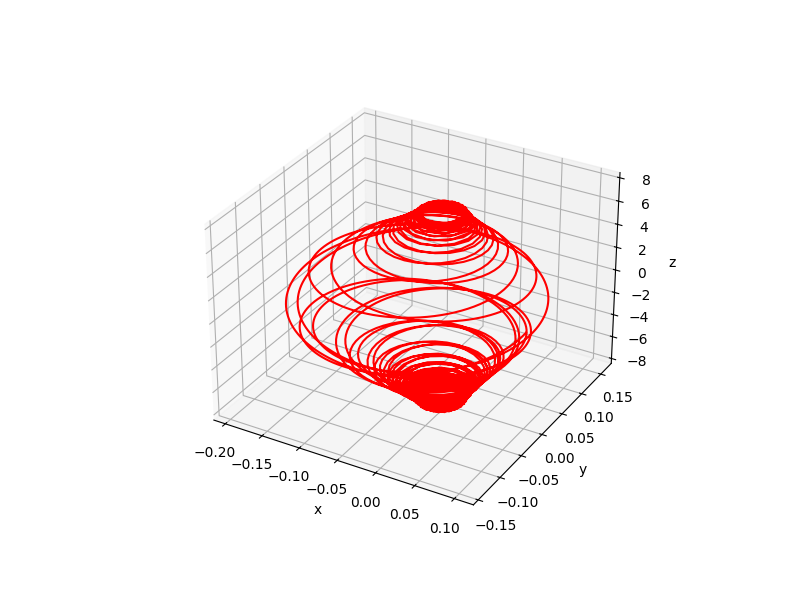

In [115]:
# Load trajectory data from CSV
# The CSV file should contain columns: t, x, y, z
root_dir = os.getcwd()
data = pd.read_csv(os.path.join(root_dir, 'data/Assignment_7_data.csv'))


time = data["t"].values
X = tf.convert_to_tensor(data[["x", "y", "z"]].values, dtype='float32')  # Position data

# Plot the real vs numerically solved trajectory
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the real trajectory from the dataset
ax.plot(X[:, 0], X[:, 1], X[:, 2], 'r', label='Original Data')
ax.set(xlabel = 'x',ylabel='y',zlabel='z')
plt.show()


In [116]:
# Reproducibility and training hyperparameters
import random

SEED = 2003
LAMBDA_DIV = 1e-2
LEARNING_RATE = 5e-4
BATCH_SIZE = 64 #Prev  = 256
EPOCHS = 10000
BEST_MODEL_PATH = os.path.join(root_dir, "best_B_model.weights.h5")

#Epochs 400: Trajectory RMSE: 6.24739138739719
#Epochs 1000: Trajectory RMSE: 9.183713637604177
#Epochs 2000: Trajectory RMSE: 2.407874784347044
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.keras.backend.clear_session()

print(f"Reproducibility seed set to: {SEED}")
print(f"LAMBDA_DIV = {LAMBDA_DIV}")
print(f"LEARNING_RATE = {LEARNING_RATE}")
print(f"BATCH_SIZE = {BATCH_SIZE}")
print(f"EPOCHS = {EPOCHS}")
print(f"BEST_MODEL_PATH = {BEST_MODEL_PATH}")


Reproducibility seed set to: 2003
LAMBDA_DIV = 0.01
LEARNING_RATE = 0.0005
BATCH_SIZE = 64
EPOCHS = 10000
BEST_MODEL_PATH = c:\Users\miste\OneDrive\Desktop\Msc AI and Machine Learning\AI in Astrophysics and Space Science\Week7\best_B_model.weights.h5


1. **Loading the data**
- load the csv file "Assignment_7_data.csv", which contain time, and positions $(x,y,z)$ of the particle
- Compute velocity and acceleration numerically from the data.  

positions shape: (2000, 3)
velocity shape: (2000, 3)
acceleration shape: (2000, 3)


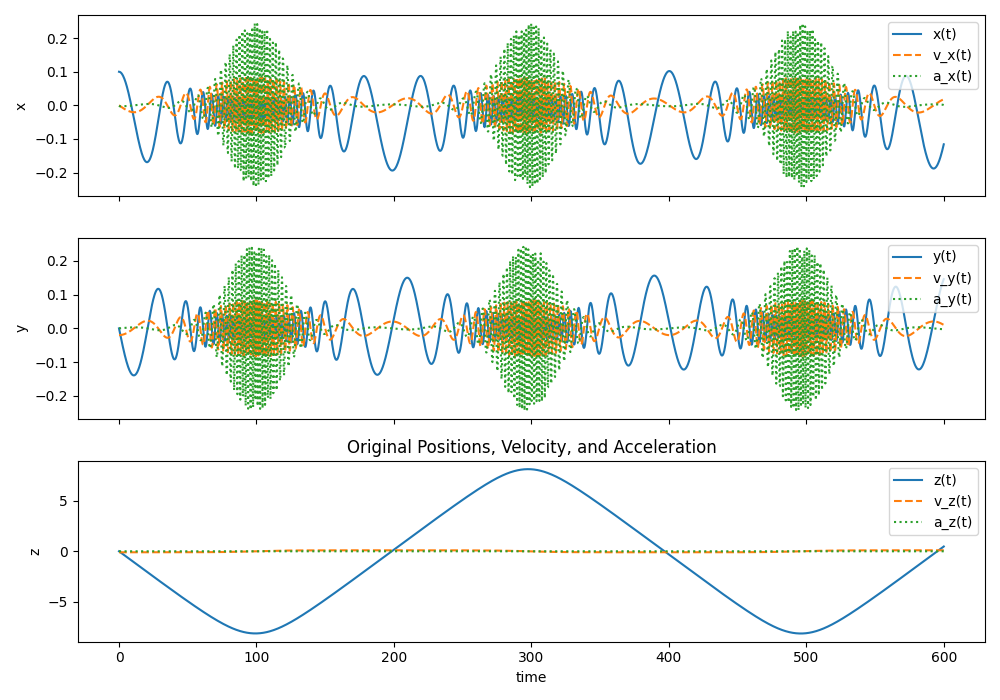

In [117]:
# Clean the dataframe and compute numerical derivatives
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]

#Store time and positions as numpy arrays for numerical differentiation
time = data["t"].to_numpy(dtype=np.float32)
positions = data[["x", "y", "z"]].to_numpy(dtype=np.float32)

# Compute velocity and acceleration using numerical differentiation
velocity = np.column_stack([
    np.gradient(positions[:, i], time) for i in range(3)
]).astype(np.float32)

acceleration = np.column_stack([
    np.gradient(velocity[:, i], time) for i in range(3)
]).astype(np.float32)

# Convert to TensorFlow tensors
X_tf = tf.convert_to_tensor(positions, dtype=tf.float32)
V_tf = tf.convert_to_tensor(velocity, dtype=tf.float32)
A_tf = tf.convert_to_tensor(acceleration, dtype=tf.float32)

print("positions shape:", positions.shape)
print("velocity shape:", velocity.shape)
print("acceleration shape:", acceleration.shape)

# Plot the original positions, velocity, and acceleration
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
labels = ["x", "y", "z"]
for i, label in enumerate(labels):
    axes[i].plot(time, positions[:, i], label=f"{label}(t)")
    axes[i].plot(time, velocity[:, i], "--", label=f"v_{label}(t)")
    axes[i].plot(time, acceleration[:, i], ":", label=f"a_{label}(t)")
    axes[i].set_ylabel(label)
    axes[i].legend(loc="upper right")

axes[-1].set_xlabel("time")
plt.title("Original Positions, Velocity, and Acceleration")
plt.tight_layout()
plt.show()


2. **Neural Network Setup**
- Define a neural network that takes $(x, y, z)$ as input and outputs $\mathbf{B}(x, y, z)$.  

In [118]:
# Small neural network that maps (x, y, z) -> (Bx, By, Bz)

# Set up a normalization layer to standardize the input positions
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(positions)

# Build the neural network model
B_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(3)
])

# Test the model with a 5 sample position inputs
sample_B = B_model(X_tf[:5])
print("Sample magnetic-field prediction shape:", sample_B.shape)


Sample magnetic-field prediction shape: (5, 3)


3. **Loss Function**
The PINN loss should consist of:
   - **Data loss:** Ensuring that the network's predictions for $\mathbf{B}$ lead to the correct acceleration via:
     $$
     L_{\text{physics}} = \left|  \frac{d^2 \mathbf{r}}{dt^2} -  (\mathbf{v} \times \mathbf{B}) \right|
     $$
   - **Physics validity:** Include the constraint that $ div(\mathbf{B})=0$. 

In [119]:
# How strongly we penalize violating the  condition: div(B) = 0

# Calculate loss for a batch of data: Lorentz-force mismatch + divergence-free penalty
def compute_losses(x_batch, v_batch, a_batch):
    with tf.GradientTape() as div_tape:
        div_tape.watch(x_batch)                     # Tell TensorFlow to track gradients with respect to the input positions
        B_pred = B_model(x_batch, training=True)    # Get the predicted magnetic field from the model for the input positions

    # Calculate partial derivatives for each component
    jacobian = div_tape.batch_jacobian(B_pred, x_batch)

    #Compute divergence  
    div_B = jacobian[:, 0, 0] + jacobian[:, 1, 1] + jacobian[:, 2, 2]

    # Compute the Lorentz acceleration from the predicted magnetic field and the input velocity
    lorentz_acc = tf.linalg.cross(v_batch, B_pred)

    # Physics loss: mean squared error between the predicted Lorentz acceleration and the true acceleration from the dataset
    physics_loss = tf.reduce_mean(
        tf.reduce_sum(tf.square(a_batch - lorentz_acc), axis=1)
    )

    # Divergence loss: mean squared value of div(B) across the batch
    div_loss = tf.reduce_mean(tf.square(div_B))

    # Total loss is a combination of the physics loss and the divergence penalty
    total_loss = physics_loss + LAMBDA_DIV * div_loss

    return total_loss, physics_loss, div_loss

# Set up an optimizer for training the model
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Define a training step function that computes the losses and applies gradients to update the model parameters
@tf.function
def train_step(x_batch, v_batch, a_batch):
    with tf.GradientTape() as tape:
        total_loss, physics_loss, div_loss = compute_losses(x_batch, v_batch, a_batch)

    gradients = tape.gradient(total_loss, B_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, B_model.trainable_variables))

    return total_loss, physics_loss, div_loss

# Test the loss function on the first 128 data points
test_loss, test_physics, test_div = compute_losses(X_tf[:128], V_tf[:128], A_tf[:128])
print("Initial total loss:", float(test_loss))
print("Initial physics loss:", float(test_physics))
print("Initial divergence loss:", float(test_div))


Initial total loss: 0.04217744991183281
Initial physics loss: 0.002596580423414707
Initial divergence loss: 3.9580869674682617


4. **Training the PINN** 
- Train the network using observed trajectories as constraints. 

Epoch  100 | loss = 0.000224 | physics = 0.000192 | div = 0.003251
Epoch  200 | loss = 0.000066 | physics = 0.000053 | div = 0.001333
Epoch  300 | loss = 0.000029 | physics = 0.000025 | div = 0.000396
Epoch  400 | loss = 0.000115 | physics = 0.000017 | div = 0.009866
Epoch  500 | loss = 0.000022 | physics = 0.000012 | div = 0.000932
Epoch  600 | loss = 0.000011 | physics = 0.000009 | div = 0.000256
Epoch  700 | loss = 0.000025 | physics = 0.000008 | div = 0.001733
Epoch  800 | loss = 0.000010 | physics = 0.000007 | div = 0.000317
Epoch  900 | loss = 0.000013 | physics = 0.000006 | div = 0.000662
Epoch 1000 | loss = 0.000018 | physics = 0.000005 | div = 0.001217
Epoch 1100 | loss = 0.000012 | physics = 0.000005 | div = 0.000638
Epoch 1200 | loss = 0.000011 | physics = 0.000005 | div = 0.000578
Epoch 1300 | loss = 0.000009 | physics = 0.000005 | div = 0.000475
Epoch 1400 | loss = 0.000007 | physics = 0.000005 | div = 0.000261
Epoch 1500 | loss = 0.000006 | physics = 0.000004 | div = 0.00

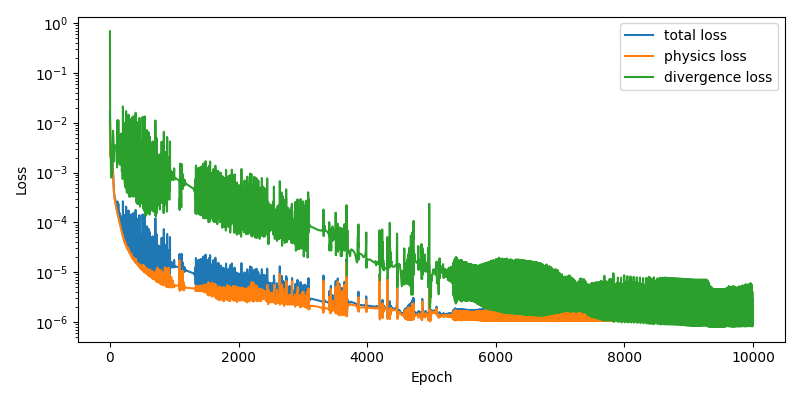

In [120]:
# Train the PINN on mini-batches of the observed trajectory
batch_size = BATCH_SIZE
epochs = EPOCHS

# Split the data into mini-batches and shuffle it for training
dataset = tf.data.Dataset.from_tensor_slices((X_tf, V_tf, A_tf))
dataset = dataset.shuffle(len(time), seed=SEED, reshuffle_each_iteration=False).batch(batch_size)


history = {"loss": [], "physics": [], "div": []} # Initialize a history dictionary to store the loss values for each epoch during training
best_loss = np.inf
best_epoch = 0

for epoch in range(1, epochs + 1):
    # Reset epoch loss accumulators at the start of each epoch
    epoch_loss = 0.0
    epoch_physics = 0.0
    epoch_div = 0.0
    n_batches = 0

    # Loop over each mini-batch in the dataset, perform a training step, and accumulate the losses for the epoch
    for x_batch, v_batch, a_batch in dataset:
        loss_value, physics_value, div_value = train_step(x_batch, v_batch, a_batch)
        epoch_loss += float(loss_value)
        epoch_physics += float(physics_value)
        epoch_div += float(div_value)
        n_batches += 1

    # After processing all batches in the epoch, compute the average losses and store them in the history dictionary
    history["loss"].append(epoch_loss / n_batches)
    history["physics"].append(epoch_physics / n_batches)
    history["div"].append(epoch_div / n_batches)

    if history["loss"][-1] < best_loss:
        best_loss = history["loss"][-1]
        best_epoch = epoch
        B_model.save_weights(BEST_MODEL_PATH)

    # Print the losses every 100 epochs to monitor training progress
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"loss = {history['loss'][-1]:.6f} | "
            f"physics = {history['physics'][-1]:.6f} | "
            f"div = {history['div'][-1]:.6f}"
        )

print(f"Best model saved at epoch {best_epoch} with loss {best_loss:.6f}")
B_model.load_weights(BEST_MODEL_PATH)

# Uses trained model to predict the magnetic field at all trajectory points in the dataset
B_pred = B_model(X_tf, training=False).numpy()

# Compute predicted accelerations from Lorentz force
acceleration_pred = np.cross(velocity, B_pred)
acceleration_rmse = np.sqrt(np.mean((acceleration - acceleration_pred) ** 2))

print("Acceleration RMSE:", acceleration_rmse)

#Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(history["loss"], label="total loss")
plt.plot(history["physics"], label="physics loss")
plt.plot(history["div"], label="divergence loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


5. **Validation** 
- Validate by testing if the inferred $\mathbf{B}$ correctly predicts the correct.  
   - Solve numerically the equation of motion using the following initial conditions:
     
      $(x,y,z)(t=0)=(0.1, 0, 0)$
     
      $(v_x,v_y,v_z) (t=0) =(0, -.02, -0.1)$
   - Compare the obtained trajectory with the one in the data (compute the RMSE between the two)
   - Make a plot of the two trajectories

Trajectory RMSE: 3.123715806761741


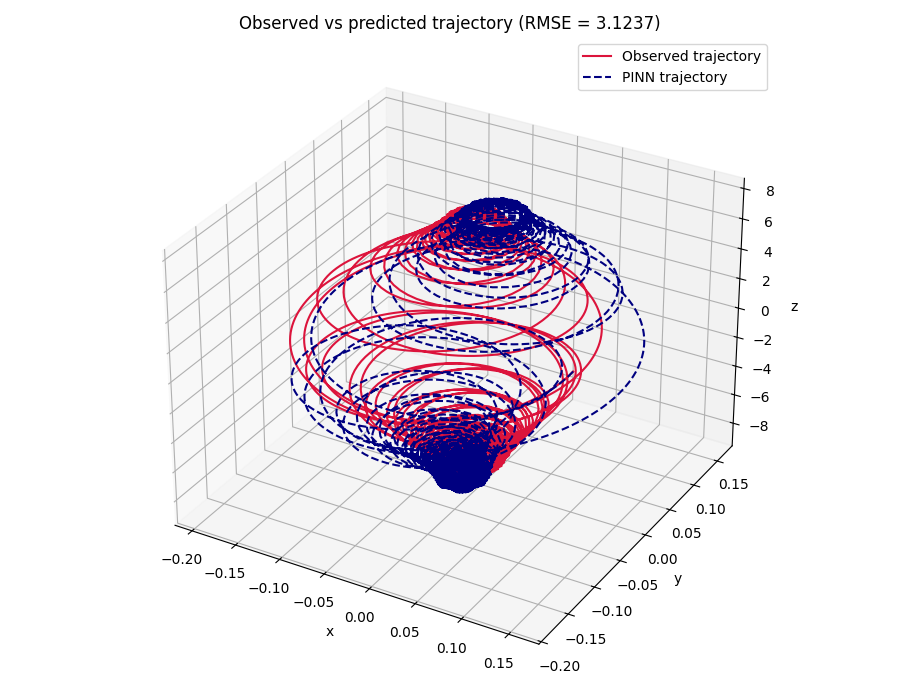

In [121]:
# Define
def lorentz_ode(state, t_value):
    #Extract position and velocity from the state vector
    position = state[:3].astype(np.float32)
    velocity_now = state[3:].astype(np.float32)

    #Asks the trained model to predict the magnetic field at the current position.
    B_here = B_model(
        tf.convert_to_tensor(position[None, :], dtype=tf.float32),
        training=False
    ).numpy()[0]

    #Compute the acceleration from the predicted magentic field and the input velocity
    acceleration_here = np.cross(velocity_now, B_here)

    # Return the concatenated velocity and acceleration as the derivative of the state vector for the ODE solver
    return np.concatenate([velocity_now, acceleration_here])

#Set starting condition 
initial_state = np.array([0.1, 0.0, 0.0, 0.0, -0.02, -0.1], dtype=np.float32)

# Integrate the Lorentz ODE using the trained model to predict the trajectory of the particle over time
solution = odeint(lorentz_ode, initial_state, time)

predicted_positions = solution[:, :3]
trajectory_rmse = np.sqrt(np.mean((predicted_positions - positions) ** 2))

print("Trajectory RMSE:", trajectory_rmse)

#Plot the observed trajectory from the dataset and the predicted trajectory fri
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(
    positions[:, 0],
    positions[:, 1],
    positions[:, 2],
    label="Observed trajectory",
    color="crimson"
)
ax.plot(
    predicted_positions[:, 0],
    predicted_positions[:, 1],
    predicted_positions[:, 2],
    label="PINN trajectory",
    color="navy",
    linestyle="--"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Observed vs predicted trajectory (RMSE = {trajectory_rmse:.4f})")
ax.legend()
plt.tight_layout()
plt.show()
